# Exploración no supervisada de jugadores del FIFA

En esta clase vamos a trabajar con un conjunto de datos de jugadores del FIFA. A diferencia de otros ejercicios anteriores, no vamos a predecir una variable objetivo, sino que vamos a usar **técnicas no supervisadas** para entender mejor la estructura del dataset.

Nuestro objetivo será descubrir grupos (o clusters) de jugadores similares entre sí, únicamente en base a sus características físicas y técnicas. Para eso, vamos a aplicar una **reducción de dimensionalidad** con PCA y después usaremos métodos de clustering como **KMeans** para encontrar patrones ocultos.

El enfoque va a ser muy parecido al de la clase anterior: encapsularemos los pasos en pipelines, haremos análisis visuales y trataremos de interpretar los resultados de manera cualitativa.

¡Empecemos! 👟⚽


# Carga y exploración inicial de los datos

Primero vamos a cargar el dataset `player-data-full.csv`, que contiene información detallada de jugadores del FIFA. Vamos a hacer una inspección general para entender qué variables hay, cuántas filas tiene y si hay valores faltantes.

Después seleccionaremos las columnas que nos interesan para el análisis no supervisado.


In [ ]:
import pandas as pd

# Cargar el dataset
!gdown 1wv6fj2uMcPj_fQKdUAsb-oDUb7o22OOD
df = pd.read_csv("player-data-full.csv")

# Mostrar dimensiones y primeras filas
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()


Downloading...
From: https://drive.google.com/uc?id=1wv6fj2uMcPj_fQKdUAsb-oDUb7o22OOD
To: /content/player-data-full.csv
100% 14.3M/14.3M [00:00<00:00, 222MB/s]
El dataset tiene 18726 filas y 76 columnas.


/tmp/ipython-input-680855524.py:5: DtypeWarning:

Columns (73) have mixed types. Specify dtype option on import or set low_memory=False.



,player_id,version,name,full_name,description,image,height_cm,weight_kg,dob,positions,...,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,play_styles
0,239085,2024-07-08,Erling Haaland,Erling Braut Haaland,"Erling Haaland (Erling Braut Haaland, born 21 ...",https://cdn.sofifa.net/players/239/085/24_120.png,195,94,2000-07-21,ST,...,87,38,47,29,7,14,13,11,7.0,"Acrobatic +,Power Header,Quick Step"
1,231747,2024-07-08,Kylian Mbappé,Kylian Mbappé Lottin,"Kylian Mbappé (Kylian Mbappé Lottin, born 20 D...",https://cdn.sofifa.net/players/231/747/24_120.png,182,75,1998-12-20,"ST,LW",...,88,26,34,32,13,5,7,11,6.0,"Quick Step +,Finesse Shot,Rapid,Flair,Trivela,..."
2,192985,2024-07-08,Kevin De Bruyne,Kevin De Bruyne,Kevin De Bruyne (born 28 June 1991) is a Belgi...,https://cdn.sofifa.net/players/192/985/24_120.png,181,75,1991-06-28,"CM,CAM",...,88,66,70,53,15,13,5,10,13.0,"Incisive Pass +,Dead Ball,Pinged Pass,Long Bal..."
3,231866,2024-07-08,Rodri,Rodrigo Hernández Cascante,Rodri (born 22 June 1996) is a Spanish footbal...,https://cdn.sofifa.net/players/231/866/24_120.png,191,82,1996-06-22,"CDM,CM",...,90,92,87,78,10,10,7,14,8.0,"Power Shot +,Long Ball Pass,Bruiser,Aerial,Lon..."
4,202126,2024-07-08,Harry Kane,Harry Kane,Harry Kane (born 28 July 1993) is a British fo...,https://cdn.sofifa.net/players/202/126/24_120.png,188,85,1993-07-28,ST,...,92,46,46,38,8,10,11,14,11.0,"Incisive Pass +,Long Ball Pass,First Touch,Tri..."


In [ ]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18726 entries, 0 to 18725
Data columns (total 76 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   player_id                  18726 non-null  int64  
 1   version                    18726 non-null  object 
 2   name                       18726 non-null  object 
 3   full_name                  18726 non-null  object 
 4   description                18726 non-null  object 
 5   image                      18726 non-null  object 
 6   height_cm                  18726 non-null  int64  
 7   weight_kg                  18726 non-null  int64  
 8   dob                        18726 non-null  object 
 9   positions                  18726 non-null  object 
 10  overall_rating             18726 non-null  int64  
 11  potential                  18726 non-null  int64  
 12  value                      18726 non-null  object 
 13  wage                       18726 non-null  obj

### Valores faltantes

Para facilitar el análisis posterior, conviene revisar si hay columnas con valores faltantes. En caso de que haya, decidiremos si imputarlos o descartarlos más adelante.


In [ ]:
# Conteo de valores faltantes sin mostrar los que tienen 0
df.isnull().sum().sort_values(ascending=False).loc[df.isnull().sum().sort_values(ascending=False) > 0]

,0
country_flag,17949
country_rating,17949
country_id,17949
country_league_name,17949
country_name,17949
country_league_id,17949
country_position,17944
country_kit_number,17944
specialities,17576
play_styles,8848


### Reflexión: ¿qué hacemos con los valores faltantes?

Como vimos en la inspección anterior, hay muchas columnas con valores faltantes, pero no todas son igual de importantes. Algunas observaciones:

- Muchas columnas relacionadas con clubes (por ejemplo, `club_name`, `club_position`, etc.) tienen valores faltantes porque probablemente corresponden a jugadores **libres** o juveniles sin contrato.
- Lo mismo sucede con columnas de arqueros como `gk_reflexes` o `gk_positioning`, que están vacías para jugadores de campo.
- La columna `play_styles` tiene muchos valores nulos porque no todos los jugadores tienen estilos asignados.
- Algunos campos como `release_clause` o `club_contract_valid_until` tienen valores faltantes incluso en jugadores con club asignado, lo cual podría indicar datos faltantes en origen.

Como estamos trabajando con aprendizaje no supervisado, es **especialmente importante** evitar que estos valores nulos interfieran en la construcción de distancias o agrupamientos. Una mala imputación puede generar ruido o incluso crear agrupamientos artificiales.

En la próxima sección, vamos a **seleccionar un subconjunto de columnas** que sean relevantes para el análisis y que tengan **mínimos valores faltantes**, priorizando atributos físicos y de rendimiento general. También vamos a planificar cómo tratar los nulos que sí estén presentes.


# Selección de variables para el análisis

Como estamos interesados en descubrir patrones en las **características físicas y de habilidad** de los jugadores, vamos a concentrarnos en un subconjunto de columnas que reflejan ese tipo de atributos.

Como primer paso vamos a cargar el dataset y a realizar una inspección **programática** para decidir qué columnas nos sirven para el análisis. Queremos que este proceso sea **automático y reproducible**, de forma que podamos incorporarlo a un pipeline sin depender de hardcodeo innecesario.

La idea es quedarnos con columnas **numéricas completas**, y excluir aquellas que sean identificadores, nombres o que tengan muchos valores faltantes. Vamos a encapsular todo en funciones reutilizables.

### ¿Cómo lo hacemos?
Vamos a crear una clase `FeatureSelector`, que se pueda insertar dentro de un `Pipeline`, y que seleccione automáticamente las columnas que cumplan estos criterios. Hardcodeamos únicamente las columnas que **sabemos** que no queremos usar (como IDs o metadatos administrativos).

Este enfoque permite que el análisis sea **robusto frente a cambios en los datos**: si se agregan o quitan columnas, mientras respeten los criterios de tipo y completitud, el pipeline va a seguir funcionando correctamente.


In [ ]:
import re
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Selecciona columnas numéricas con baja cantidad de nulos,
    excluyendo aquellas que coincidan con patrones o listas explícitas.
    """
    def __init__(self, umbral_nulos=0.05, excluir_columnas=None, excluir_patrones=None):
        self.umbral_nulos = umbral_nulos
        self.excluir_columnas = excluir_columnas or []
        self.excluir_patrones = excluir_patrones or []

    def fit(self, X, y=None):
        columnas_numericas = X.select_dtypes(include=["number"]).columns
        proporcion_nulos = X[columnas_numericas].isnull().mean()

        columnas_utiles = [
            col for col in columnas_numericas
            if proporcion_nulos[col] <= self.umbral_nulos
        ]

        # Exclusión por nombre directo o por patrón
        self.columnas_seleccionadas_ = [
            col for col in columnas_utiles
            if col not in self.excluir_columnas
            and not any(pat in col for pat in self.excluir_patrones)
        ]
        return self

    def transform(self, X):
        return X[self.columnas_seleccionadas_]


In [ ]:
# Definimos reglas de exclusión
excluir_columnas = []  # si queremos algunas explícitas
excluir_patrones = ["_id", "_name", "_number", "club_"]

selector = FeatureSelector(
    umbral_nulos=0.05,
    excluir_columnas=excluir_columnas,
    excluir_patrones=excluir_patrones
)

df_filtrado = selector.fit_transform(df)
print(f"Columnas seleccionadas: {df_filtrado.shape[1]}")
df_filtrado.columns



Columnas seleccionadas: 40


Index(['height_cm', 'weight_kg', 'overall_rating', 'potential', 'weak_foot',
       'skill_moves', 'international_reputation', 'crossing', 'finishing',
       'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve',
       'fk_accuracy', 'long_passing', 'ball_control', 'acceleration',
       'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power',
       'jumping', 'stamina', 'strength', 'long_shots', 'aggression',
       'interceptions', 'positioning', 'vision', 'penalties', 'composure',
       'defensive_awareness', 'standing_tackle', 'sliding_tackle', 'gk_diving',
       'gk_handling', 'gk_kicking', 'gk_reflexes'],
      dtype='object')

# Reducción de dimensionalidad con PCA

En esta sección vamos a transformar nuestro dataset con muchas variables numéricas (40, tras la selección anterior) a un nuevo espacio de menor dimensión, que conserve la mayor parte posible de la información.

Esto se logra mediante **Análisis de Componentes Principales (PCA)**, una técnica lineal que reordena las variables en nuevas combinaciones ortogonales (llamadas componentes principales), ordenadas según cuánta varianza explican.

Vamos a hacerlo de forma modular y reutilizable, respetando el mismo criterio de encapsulamiento visto antes: todo se integrará en **pipelines de Scikit-Learn**.


### ¿Por qué aplicar PCA?

Existen varias motivaciones prácticas para aplicar reducción de dimensionalidad:

- **Visualización:** al proyectar a 2D o 3D podemos graficar y descubrir estructuras naturales (grupos, separaciones, outliers).
- **Eliminación de redundancia:** muchas variables originales están correlacionadas (por ejemplo, velocidad y aceleración).
- **Mejora de performance:** al reducir dimensiones se simplifican tareas posteriores (clustering, clasificación no supervisada).


### Dos enfoques complementarios para PCA

En este notebook usamos dos enfoques distintos pero complementarios para aplicar PCA, según el objetivo buscado. Ambos enfoques comparten la misma estructura de preprocesamiento:

 imputación → escalado → PCA.

 Pero se diferencian en su **criterio de corte** y en el **propósito analítico** que persiguen.



#### PCA adaptativo
- Este pipeline determina automáticamente cuántas componentes mantener para alcanzar un **umbral de varianza acumulada** (por ejemplo, el 80 % o 95 %).
- Es útil cuando queremos **reducir dimensionalidad sin perder demasiada información**.
- El número de componentes puede variar según los datos y se informa al final del `fit()`.

Ideal para:  
- Entrenar modelos sobre datos reducidos.  
- Evitar overfitting por exceso de variables.  
- Acelerar clustering sin perder contenido informativo.





In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


class PCAReducerByVariance(BaseEstimator, TransformerMixin):
    """
    Pipeline de imputación + escalado + PCA.
    Selecciona automáticamente el número de componentes necesarias
    para alcanzar una varianza acumulada dada.

    Permite visualizar manualmente la varianza acumulada y la composición
    lineal de las componentes principales mediante métodos públicos.
    """
    def __init__(self, varianza_objetivo=0.95):
        self.varianza_objetivo = varianza_objetivo

    def fit(self, X, y=None):
        self.feature_names_ = list(X.columns)

        # Preprocesamiento para estimar varianza acumulada completa
        X_proc = SimpleImputer(strategy="median").fit_transform(X)
        X_proc = StandardScaler().fit_transform(X_proc)

        # PCA con todos los componentes para calcular varianza acumulada
        pca_temp = PCA().fit(X_proc)
        self.varianza_acumulada_ = pca_temp.explained_variance_ratio_.cumsum()

        # Determinar la cantidad mínima de componentes
        self.n_componentes_ = (self.varianza_acumulada_ >= self.varianza_objetivo).argmax() + 1
        print(f"\n✅ Se necesitan {self.n_componentes_} componentes para explicar al menos el {self.varianza_objetivo:.2%} de la varianza.")

        # Pipeline definitivo
        self.pipeline_ = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=self.n_componentes_))
        ])
        self.pipeline_.fit(X)

        return self

    def transform(self, X):
        return self.pipeline_.transform(X)

    def plot_varianza_acumulada(self):
        if not hasattr(self, "varianza_acumulada_"):
            raise RuntimeError("Debés ajustar el modelo con fit() antes de graficar.")

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(self.varianza_acumulada_)+1), self.varianza_acumulada_, marker="o")
        plt.axhline(self.varianza_objetivo, color="gray", linestyle="--", label=f"{self.varianza_objetivo:.0%} de varianza")
        plt.title("Varianza acumulada por número de componentes")
        plt.xlabel("Número de componentes principales")
        plt.ylabel("Varianza acumulada")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_heatmap_componentes(self):
        if not hasattr(self, "pipeline_"):
            raise RuntimeError("Debés ajustar el modelo con fit() antes de graficar.")

        pca = self.pipeline_.named_steps["pca"]
        componentes = pca.components_
        df_comp = pd.DataFrame(
            data=componentes,
            columns=self.feature_names_,
            index=[f"PC{i+1}" for i in range(componentes.shape[0])]
        ).T  # Transponer para variables como filas

        plt.figure(figsize=(max(10, 0.5 * self.n_componentes_), 0.3 * len(self.feature_names_)))
        sns.heatmap(df_comp, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar=True)
        plt.title(f"Contribución de cada variable a las primeras {self.n_componentes_} componentes")
        plt.xlabel("Componentes principales")
        plt.ylabel("Variables originales")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def get_num_componentes(self):
        return self.n_componentes_

    def get_componentes_dataframe(self):
        pca = self.pipeline_.named_steps["pca"]
        return pd.DataFrame(
            data=pca.components_,
            columns=self.feature_names_,
            index=[f"PC{i+1}" for i in range(pca.n_components_)]
        )


In [ ]:
pca = PCAReducerByVariance(varianza_objetivo=0.80)
X_reducido = pca.fit_transform(df_filtrado)



✅ Se necesitan 5 componentes para explicar al menos el 80.00% de la varianza.


##### Interpretación del gráfico de varianza acumulada

El gráfico muestra cuánta **varianza total del dataset** es explicada a medida que aumentamos el número de componentes principales.



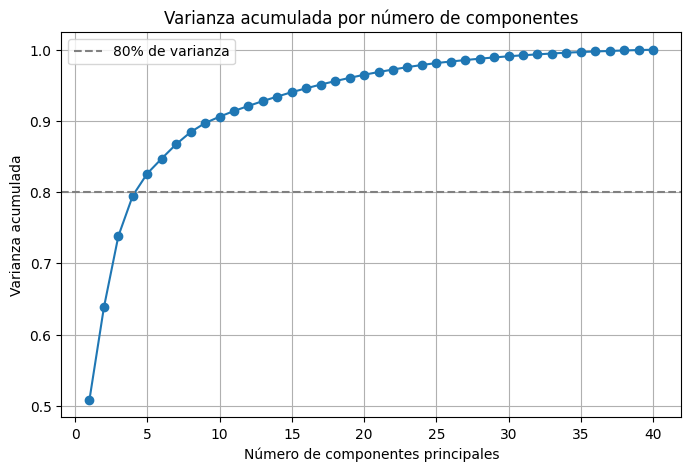

In [ ]:
pca.plot_varianza_acumulada()

Observaciones clave:

- Las primeras **5 componentes** explican aproximadamente el **80 % de la varianza** total.  
  Esto indica que podemos reducir de 40 a solo 5 dimensiones sin perder demasiada información.
  
- A partir de la componente 10 en adelante, las ganancias de varianza son **marginales**: agregar más componentes no aporta tanto.

- Este gráfico guía la elección de cuántas dimensiones mantener en nuestro pipeline. En este caso, configuramos `PCAReducerByVariance` con un umbral del 80 %, lo que automáticamente seleccionó las primeras 5 componentes.


##### Interpretación tentativa del heatmap de componentes

El heatmap muestra cuánto aporta cada variable original a la construcción de las primeras 5 componentes principales.  





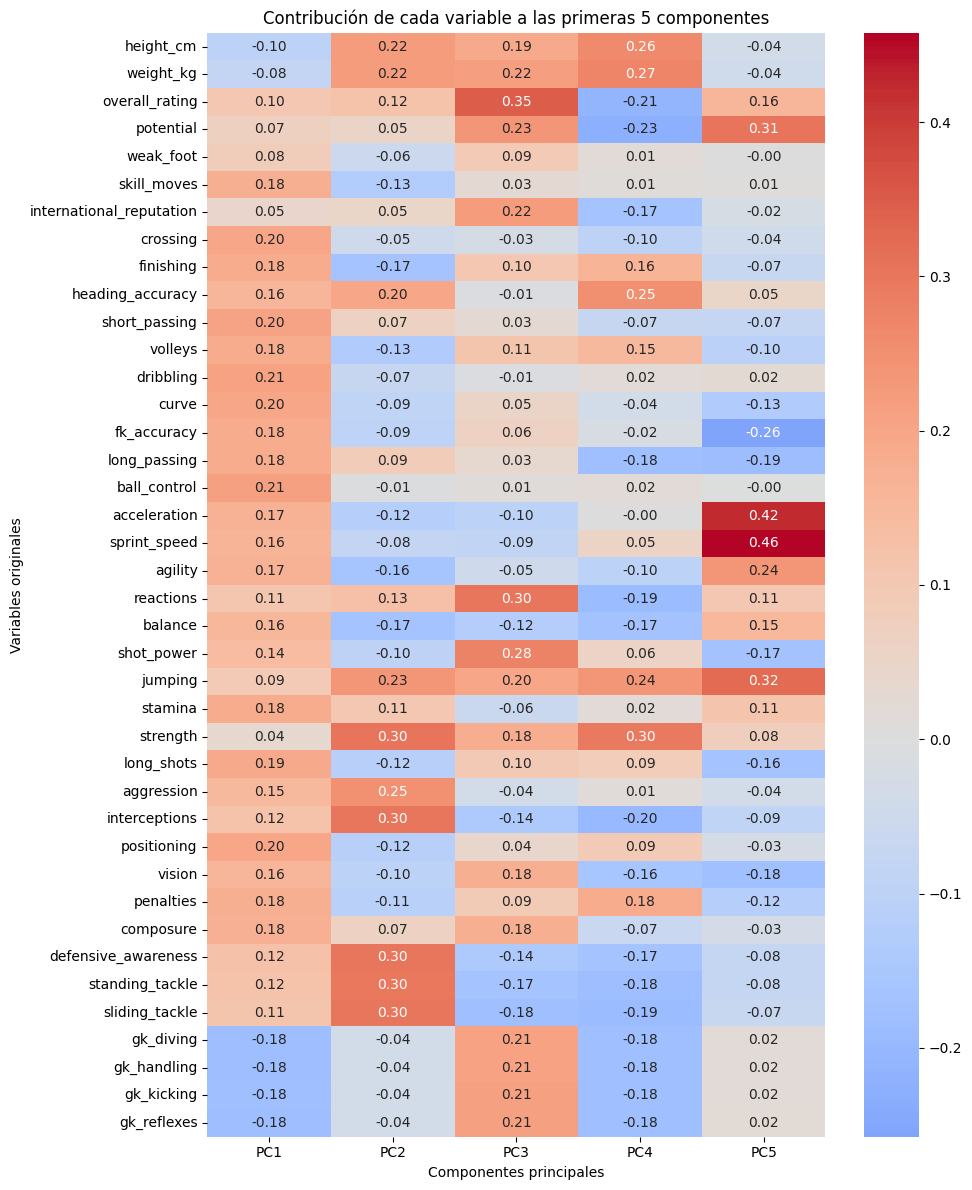

In [ ]:
pca.plot_heatmap_componentes()

Estas combinaciones lineales no tienen un significado intrínseco, pero podemos intentar **interpretarlas a priori** en base a qué variables dominan cada componente:

- **PC1**: Tiene cargas importantes en variables técnicas ofensivas como `dribbling`, `ball_control`, `curve`, `crossing`, y también en `acceleration`. Podría representar un **perfil técnico-ofensivo y ágil**.

- **PC2**: Sobresale en variables físicas como `strength`, `interceptions`, `sliding_tackle`, `standing_tackle`, `defensive_awareness`. Esta componente parece captar la **fuerza y capacidad defensiva** del jugador.

- **PC3**: Muestra aportes fuertes de `overall_rating`, `shot_power`, `composure`, `vision`, y también en variables de arqueros (`gk_diving`, `gk_kicking`). Esta combinación sugiere un **componente de rendimiento general o versatilidad**, mezclando calidad ofensiva y atributos de arquero.

- **PC4**: Tiene cargas importantes en `potential` (negativa), `acceleration`, `balance`, y algunas de arquero (`gk_reflexes`). No es tan clara, pero podría estar ligada a **condición física y proyección**.

- **PC5**: Está dominada fuertemente por `sprint_speed` y `acceleration`. Es probable que capture puramente la **velocidad explosiva** del jugador.

> ⚠️ Estas interpretaciones son tentativas y **no deben tomarse como verdades absolutas**. PCA no garantiza que las componentes tengan significado semántico directo.  
Sin embargo, este análisis puede ayudar a orientar la comprensión de los ejes latentes del dataset.

#### PCA fijo para visualización
- Este pipeline aplica siempre **una cantidad fija de componentes principales**, sin importar cuánta varianza explican.
- Está pensado exclusivamente para **visualización**.
- Permite graficar scatterplots coloreados por etiquetas o categorías como la posición del jugador.

Ideal para:  
- Explorar la estructura del dataset.  
- Detectar posibles agrupamientos visuales.  
- Comprobar si ciertas clases (como los arqueros) se separan naturalmente.



In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

class PCAPipeline(BaseEstimator, TransformerMixin):
    """
    Pipeline que aplica imputación + escalado + PCA a n componentes.
    """
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=self.n_components))
        ])

    def fit(self, X, y=None):
        self.pipeline.fit(X)
        return self

    def transform(self, X):
        return self.pipeline.transform(X)

    def get_pca_model(self):
        return self.pipeline.named_steps["pca"]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_scatter_pca(X_pca, etiquetas=None, titulo="Proyección en 2D por PCA"):
    """
    Grafica un scatterplot con los dos primeros componentes principales.

    Parámetros:
    - X_pca: ndarray o DataFrame con al menos 2 columnas (PC1, PC2).
    - etiquetas: opcional, Series o array para colorear los puntos.
    - titulo: título del gráfico.
    """
    if isinstance(X_pca, pd.DataFrame):
        x = X_pca.iloc[:, 0]
        y = X_pca.iloc[:, 1]
    else:
        x = X_pca[:, 0]
        y = X_pca[:, 1]

    plt.figure(figsize=(8, 6))
    if etiquetas is None:
        plt.scatter(x, y, alpha=0.5, s=10)
    else:
        sns.scatterplot(x=x, y=y, hue=etiquetas, palette="Set2", alpha=0.6, s=20)

    plt.title(titulo)
    plt.xlabel("Componente principal 1")
    plt.ylabel("Componente principal 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


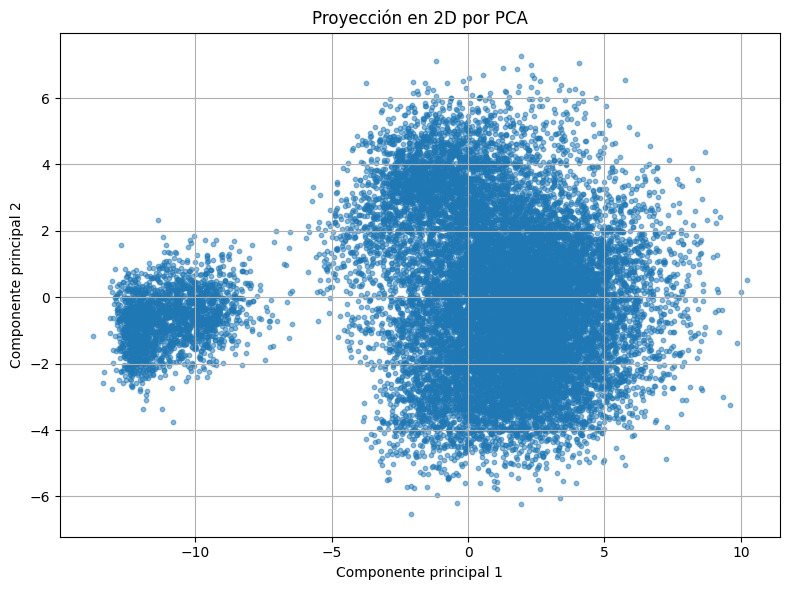

In [ ]:
pipe_pca_2d = Pipeline([
    ("selector", FeatureSelector(
        umbral_nulos=0.05,
        excluir_patrones=["_id", "_name", "_number", "club_"]
    )),
    ("pca", PCAPipeline(n_components=2))
])

X_reducido_2d = pipe_pca_2d.fit_transform(df)
# Gráfico de dispersión sin etiquetas
plot_scatter_pca(X_reducido_2d)

##### ¿Qué vemos en la proyección 2D por PCA?

La proyección 2D muestra una estructura con **dos grupos claramente distinguibles**:

- Un **grupo compacto, denso y bien definido a la izquierda**, separado del resto por un "canal" de baja densidad.
- Un **grupo mucho más disperso y grande a la derecha**, con forma más circular y bordes difusos.

Este patrón es una señal fuerte de que **ya existe una separación natural** en el dataset, incluso sin aplicar clustering explícito.



##### ¿Por qué colorear por posición? ¿Y qué pasa con los arqueros?

Hasta este punto veníamos trabajando de forma puramente no supervisada, sin usar ninguna información de clase. Sin embargo, decidimos hacer un pequeño desvío para **colorear la proyección PCA en 2D según la posición del jugador**, con el objetivo de interpretar mejor las estructuras emergentes.

Este tipo de análisis es totalmente válido porque:
- **No usamos la posición como feature** de entrada en el PCA.
- Solo la utilizamos **después**, para observar si las posiciones se alinean con la estructura proyectada.

Una hipótesis muy probable que surge al observar el gráfico es que el **grupo pequeño y bien separado a la izquierda** corresponde a los **arqueros**, ya que:

- Tienen un perfil técnico muy distinto (por ejemplo, `gk_reflexes`, `gk_diving`, etc.).
- Son una minoría dentro del conjunto de jugadores.
- Su separación se logró **sin haber entrenado el modelo con esa etiqueta**, lo que indica que el PCA está captando diferencias estructurales reales.

Para facilitar este análisis visual, agregamos un paso en el pipeline que:
- Extrae la primera posición listada del jugador (`positions`).
- La traduce a categorías amplias como "Arquero", "Volante", etc.
- Devuelve un DataFrame enriquecido con las columnas `posicion_simplificada` y `es_arquero`.

Esta modificación mantiene el espíritu reproducible del enfoque, integrando el etiquetado y la visualización dentro de un pipeline modular y trazable.


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class PosicionSimplificada(BaseEstimator, TransformerMixin):
    """
    Agrega dos columnas al dataframe:
    - 'posicion_simplificada': una categoría agrupada (Arquero, Volante, etc.)
    - 'es_arquero': 1 si es arquero, 0 si es jugador de campo
    """
    def __init__(self, columna_original="positions"):
        self.columna_original = columna_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Extraer primera posición
        X["posicion_principal"] = (
            X[self.columna_original]
            .astype(str)
            .str.split(",")
            .str[0]
            .str.strip()
        )

        # Mapear a categorías simplificadas
        mapa_posiciones = {
            "GK": "Arquero",
            "CB": "Defensor central",
            "RB": "Lateral", "LB": "Lateral", "RWB": "Lateral", "LWB": "Lateral",
            "CDM": "Volante defensivo",
            "CM": "Volante", "CAM": "Volante", "RM": "Volante", "LM": "Volante",
            "ST": "Delantero", "CF": "Delantero",
            "RW": "Extremo", "LW": "Extremo",
        }

        X["posicion_simplificada"] = X["posicion_principal"].map(mapa_posiciones)
        X["es_arquero"] = (X["posicion_simplificada"] == "Arquero").astype(int)
        return X


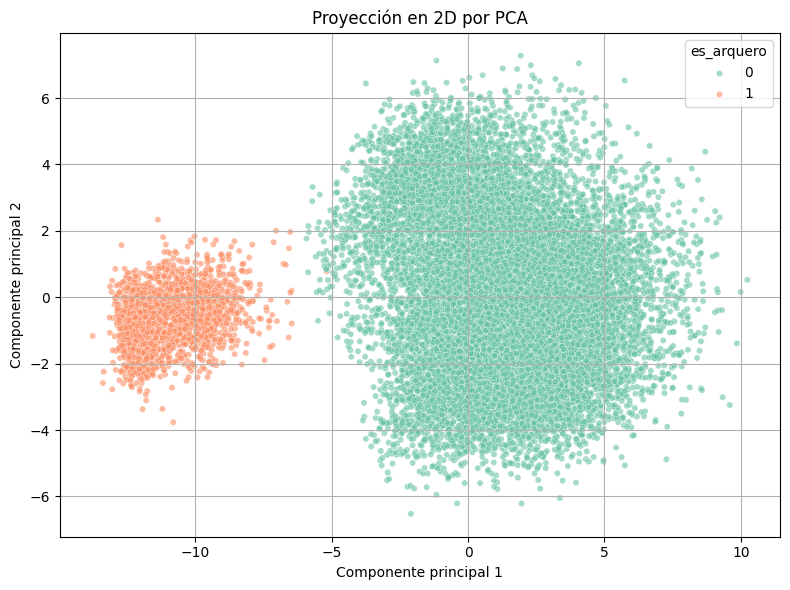

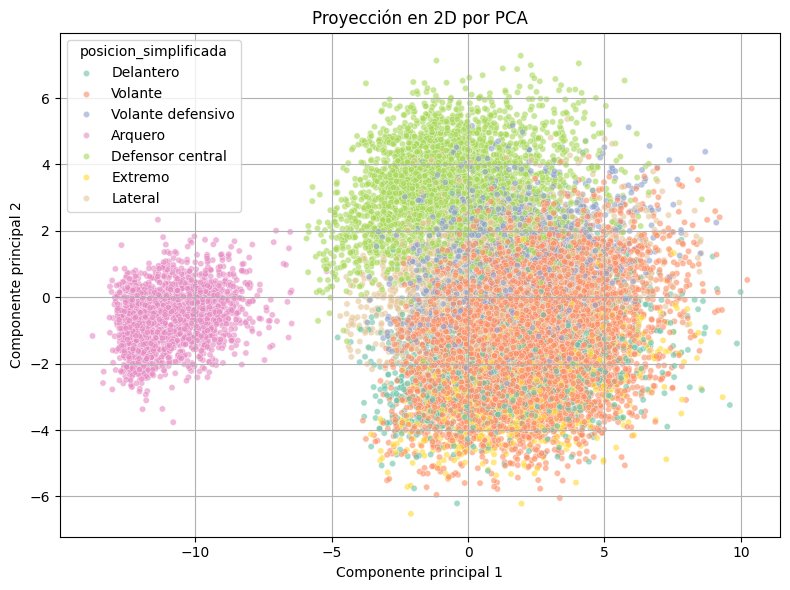

In [ ]:
df_posiciones = PosicionSimplificada().fit_transform(df)

# Gráfico de dispersión sin etiquetas
plot_scatter_pca(X_reducido_2d, etiquetas=df_posiciones["es_arquero"])
plot_scatter_pca(X_reducido_2d, etiquetas=df_posiciones["posicion_simplificada"])

###### Interpretación del gráfico PCA 2D coloreado por posición

Este gráfico muestra la proyección en dos dimensiones principales (PC1 y PC2) de los jugadores, coloreada por su posición simplificada. Es el resultado de un proceso puramente no supervisado: el PCA no "sabía" la posición de los jugadores al momento de generar estas componentes.

Observaciones clave:

- El grupo de **arqueros** (en rojo, a la izquierda) forma un **clúster compacto, bien separado** del resto.  
  Esto confirma nuestra hipótesis: los arqueros tienen un perfil técnico y físico tan distinto que su separación emerge de manera natural sin necesidad de etiquetarlos.

- El resto de las posiciones forma un **gran clúster principal**, con cierta estructura interna:
  - Los **defensores centrales** (violeta) se concentran en la parte superior.
  - Los **volantes** (naranja) y **delanteros** (azul) se superponen bastante, pero tienden a ocupar zonas ligeramente distintas.
  - Los **extremos** y **laterales** aparecen más dispersos, ocupando zonas periféricas.

- Se observan **gradientes y transiciones suaves** entre roles afines, lo que tiene sentido desde el punto de vista del fútbol real: no hay una frontera nítida entre un lateral ofensivo y un extremo, por ejemplo.

En resumen, este gráfico nos permite **validar que el PCA está captando dimensiones latentes que reflejan roles funcionales reales** dentro del campo de juego, incluso en un contexto no supervisado. Además, nos ofrece una base visual para futuras tareas de clustering o segmentación.


##### Exploración en 3D: ¿podemos separar mejor los grupos?

Aunque la proyección en 2D ya reveló cierta estructura interesante (sobre todo la clara separación de arqueros), el clúster principal que agrupa a defensores, volantes y atacantes sigue siendo bastante denso y superpuesto.

Por eso decidimos **explorar una proyección en 3 dimensiones**, manteniendo el mismo enfoque no supervisado pero agregando una dimensión más al espacio PCA. ¿Por qué puede valer la pena?

- **Más grados de libertad** → puede revelar separaciones que en 2D están colapsadas.
- **Disociar subconjuntos internos** dentro del grupo principal.
- **Validar visualmente** si ciertas posiciones como laterales o extremos ocupan zonas más diferenciadas cuando agregamos una tercera dimensión.

Esta exploración 3D no reemplaza la visualización en 2D (que sigue siendo más clara para análisis rápidos), pero puede **ofrecer una vista complementaria** para entender mejor la estructura latente del dataset.

En este caso, usamos la función  `plot_3d_pca`, para graficar en un scatter 3D interactivo con Plotly.


In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

def plot_3d_pca(X_pca, etiquetas=None, titulo="Proyección PCA (3D)"):
    """
    Grafica la proyección de datos en 3D usando Plotly.

    Parámetros:
    - X_pca: ndarray o DataFrame con al menos 3 columnas (PC1, PC2, PC3)
    - etiquetas: opcional, Series o array para colorear los puntos.
    - titulo: título del gráfico
    """
    if isinstance(X_pca, np.ndarray):
        X_pca = pd.DataFrame(X_pca, columns=["pca_1", "pca_2", "pca_3"])

    df_plot = X_pca.copy()
    if etiquetas is not None:
        df_plot["etiqueta"] = etiquetas
    else:
        df_plot["etiqueta"] = "Punto"

    fig = px.scatter_3d(
        df_plot,
        x="pca_1", y="pca_2", z="pca_3",
        color="etiqueta",
        opacity=0.6,
        title=titulo
    )
    fig.update_traces(marker=dict(size=3))
    fig.show()



In [ ]:
pipe_pca_3d = Pipeline([
    ("selector", FeatureSelector(
        umbral_nulos=0.05,
        excluir_patrones=["_id", "_name", "_number", "club_"]
    )),
    ("pca", PCAPipeline(n_components=3))
])

X_reducido_3d = pipe_pca_3d.fit_transform(df)
# Gráfico de dispersión sin etiquetas
plot_3d_pca(X_reducido_3d)

In [ ]:
df_posiciones = PosicionSimplificada().fit_transform(df)

# Gráfico de dispersión sin etiquetas
plot_3d_pca(X_reducido_3d, etiquetas=df_posiciones["es_arquero"])
plot_3d_pca(X_reducido_3d, etiquetas=df_posiciones["posicion_simplificada"])

###### ¿Qué aporta la proyección en 3D?

El análisis tridimensional confirma varias observaciones previas y aporta algunos matices adicionales:

 Confirmación del clúster de arqueros
- El grupo de **arqueros** (violeta) aparece claramente **aislado en un extremo del espacio PCA**.
- La separación es aún más notoria en 3D que en 2D, con una **distancia clara en las tres dimensiones** respecto del resto.
- Esto valida que el PCA capta características específicas del perfil de arquero sin haber entrenado con etiquetas.

Estructura interna del clúster principal
- El **resto de las posiciones** forma una nube principal con cierta forma **elipsoidal aplanada**, lo que explica por qué en 2D se ve tan superpuesto.
- En 3D se aprecian **ciertos gradientes internos**:
  - **Defensores** y **volantes defensivos** tienden a ocupar zonas más alejadas del centro.
  - **Delanteros** y **extremos** se agrupan más hacia el núcleo del volumen.
  - **Laterales** aparecen como una capa envolvente, dispersa pero coherente.

Importancia de rotar la vista
- La rotación del gráfico permite encontrar **ángulos donde la separación entre roles es más evidente**.
- Algunos patrones no eran visibles en la proyección 2D y emergen claramente al **observar desde el eje de la tercera componente** (`pca_3`).


# Clustering no supervisado

Una vez proyectado el dataset a un espacio de menor dimensión con PCA, podemos aplicar técnicas de **clustering** para descubrir grupos latentes en los datos.

Trabajaremos con el algoritmo **KMeans**, que agrupa observaciones en torno a centroides optimizando la varianza intra-cluster.

### ¿Sobre qué espacio aplicamos el clustering?

Aplicamos el clustering **no sobre las variables originales**, sino sobre las coordenadas generadas por PCA:

- Esto reduce el ruido y las redundancias.  
- Evita la necesidad de escalar y tratar valores faltantes otra vez (ya lo hizo el pipeline de PCA).  
- Mejora la forma de los clusters (el PCA tiende a "esferizar" los datos, algo que ayuda a KMeans).

Por simplicidad, empezamos con la proyección 2D (`pca_1`, `pca_2`), pero luego también probaremos con la del 80% de varianza conservada


## ¿Cuántos clusters elegir?

En lugar de fijar manualmente la cantidad de clusters `k`, vamos a dejar que el modelo la elija automáticamente usando el **Silhouette Score**.

Este score mide **qué tan bien separado** está cada cluster, comparando la distancia promedio entre puntos del mismo grupo vs. de otros grupos. Cuanto más alto el score (máximo 1), **mejor es la separación** entre clusters.

El proceso consiste en:
- Probar distintos valores de `k` dentro de un rango razonable (por ejemplo, de 2 a 10).
- Para cada uno, calcular el Silhouette Score promedio.
- Elegir automáticamente el `k` que **maximiza ese score**.

Este enfoque nos permite adaptar el número de grupos según la estructura real de los datos proyectados por PCA.


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

class KMeansAutoCluster(BaseEstimator, TransformerMixin):
    """
    Aplica KMeans eligiendo automáticamente la mejor cantidad de clusters
    según el Silhouette Score. Permite graficar la curva resultante y acceder
    al valor óptimo de k y a las etiquetas generadas.
    """
    def __init__(self, k_range=range(2, 11), random_state=42):
        self.k_range = list(k_range)
        self.random_state = random_state

    def fit(self, X, y=None):
        self.inertias_ = []
        self.silhouettes_ = []
        self.k_models_ = {}

        for k in self.k_range:
            model = KMeans(n_clusters=k, random_state=self.random_state, n_init="auto")
            labels = model.fit_predict(X)
            self.k_models_[k] = model
            self.inertias_.append(model.inertia_)
            self.silhouettes_.append(silhouette_score(X, labels))

        self.k_optimo_ = self.k_range[np.argmax(self.silhouettes_)]
        print(f"el número de clusters óptimo es {self.k_optimo_} con un índice de silueta de {max(self.silhouettes_)} \n")
        self.best_model_ = self.k_models_[self.k_optimo_]
        self.labels_ = self.best_model_.predict(X)
        return self.best_model_.fit(X)

    def predict(self, X):
        return self.best_model_.predict(X)

    def get_labels(self):
        return self.labels_

    def get_optimal_k(self):
        return self.k_optimo_

    def plot_silhouette_curve(self):
        plt.figure(figsize=(6, 4))
        plt.plot(self.k_range, self.silhouettes_, marker="o", color="green")
        plt.axvline(self.k_optimo_, color="gray", linestyle="--", label=f"k óptimo = {self.k_optimo_}")
        plt.title("Silhouette Score vs cantidad de clusters")
        plt.xlabel("Número de clusters")
        plt.ylabel("Silhouette Score")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [ ]:
# Clustering automático
selector = FeatureSelector(
    umbral_nulos=0.05,
    excluir_patrones=["_id", "_name", "_number", "club_"]
)
pca2d = PCAPipeline(n_components=2)
pca3d = PCAPipeline(n_components=3)
pca5d = PCAPipeline(n_components=5)


pipe_autocluster_2d = Pipeline([
    ("selector", selector),
    ("pca", pca2d),
    ("cluster", KMeansAutoCluster())
])

pipe_autocluster_3d = Pipeline([
    ("selector", selector),
    ("pca", pca3d),
    ("cluster", KMeansAutoCluster())
])

pipe_autocluster_5d = Pipeline([
    ("selector", selector),
    ("pca", pca5d),
    ("cluster", KMeansAutoCluster())
])

pipe_autocluster_2d.fit(df)
pipe_autocluster_3d.fit(df)
pipe_autocluster_5d.fit(df)

el número de clusters óptimo es 2 con un índice de silueta de 0.6604268581551467 

el número de clusters óptimo es 2 con un índice de silueta de 0.6297453847912429 

el número de clusters óptimo es 2 con un índice de silueta de 0.5880463965185811 



Pipeline(steps=[('selector',
                 FeatureSelector(excluir_columnas=[],
                                 excluir_patrones=['_id', '_name', '_number',
                                                   'club_'])),
                ('pca', PCAPipeline(n_components=5)),
                ('cluster',
                 KMeansAutoCluster(k_range=[2, 3, 4, 5, 6, 7, 8, 9, 10]))])

In [ ]:
import matplotlib.pyplot as plt

def plot_multiple_silhouettes(modelos, nombres=None, figsize=(5, 4)):
    """
    Dibuja los gráficos de Silhouette Score de múltiples modelos KMeansAutoCluster en una sola fila.

    Parámetros:
    - modelos: lista de objetos KMeansAutoCluster ya entrenados
    - nombres: lista de títulos opcionales para cada subplot
    - figsize: tamaño base de cada gráfico individual (ancho, alto)
    """
    n = len(modelos)
    fig, axes = plt.subplots(1, n, figsize=(figsize[0]*n, figsize[1]), sharey=True)

    if n == 1:
        axes = [axes]

    for i, (modelo, ax) in enumerate(zip(modelos, axes)):
        k_range = modelo.k_range
        sils = modelo.silhouettes_
        k_opt = modelo.get_optimal_k()

        ax.plot(k_range, sils, marker="o", color="green")
        ax.axvline(k_opt, color="gray", linestyle="--", label=f"k óptimo = {k_opt}")
        ax.set_xlabel("Clusters (k)")
        if i == 0:
            ax.set_ylabel("Silhouette Score")
        if nombres:
            ax.set_title(nombres[i])
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


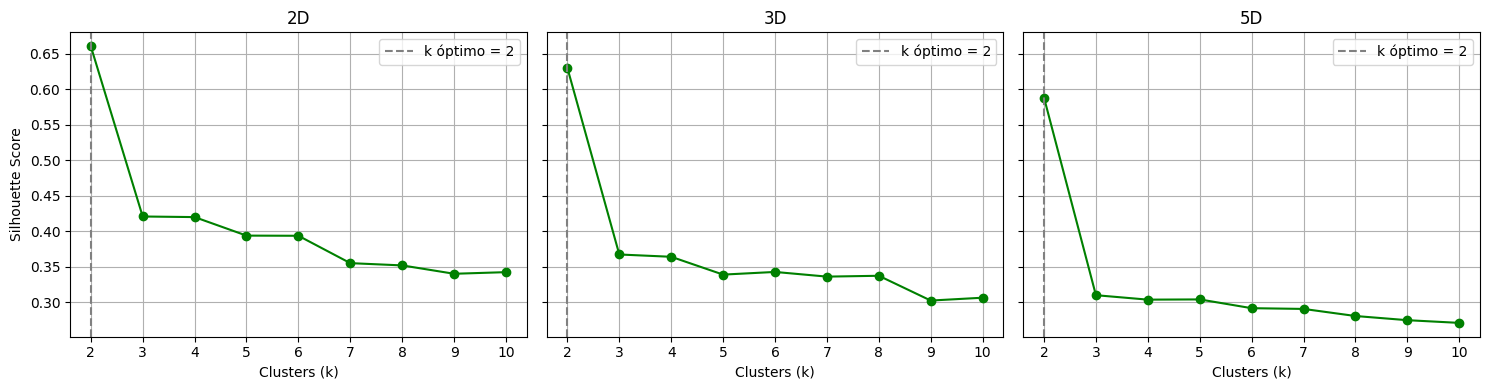

In [ ]:
plot_multiple_silhouettes(
    [pipe_autocluster_2d["cluster"], pipe_autocluster_3d["cluster"], pipe_autocluster_5d["cluster"]],
    nombres=["2D", "3D", "5D"]
)

###  Interpretación del gráfico de Silhouette Score

El gráfico muestra cómo varía el **Silhouette Score promedio** a medida que cambiamos la cantidad de clusters `k`.

 **¿Qué representa este score?**
- Mide cuán bien separado está cada cluster, comparando qué tan cerca está cada punto de su propio grupo frente a los demás.
- Su valor va de -1 a 1:
  - **1** → clusters compactos y muy separados.
  - **0** → los puntos están en el límite entre grupos.
  - **< 0** → posible mala asignación.

 **¿Qué observamos?**
- El score más alto se alcanza con **k = 2**, lo que indica que esa cantidad de clusters **produce la segmentación más nítida** en el espacio proyectado por PCA.
- A partir de k = 3, el score disminuye rápidamente y se estabiliza, lo que sugiere que **los nuevos clusters están poco definidos** o generan solapamientos.

 Por eso, el algoritmo elige automáticamente **k = 2** como la mejor opción para capturar la estructura latente de los datos, según esta métrica.


# Interpretación de los clusters obtenidos

Veamos los clusters obtenidos para dos dimensiones de PCA

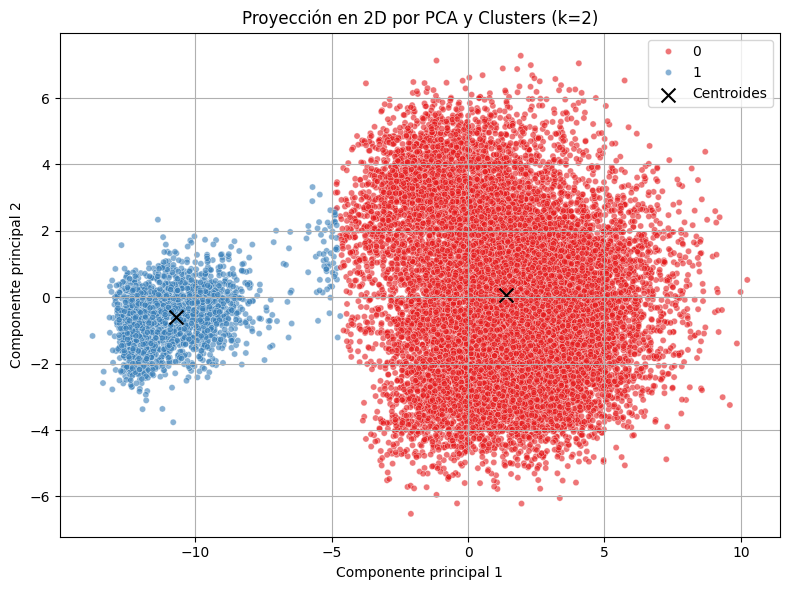

In [ ]:
# Obtener los datos proyectados en 2D y las etiquetas de cluster
X_reducido_2d = pipe_autocluster_2d.named_steps["pca"].transform(df_filtrado)
etiquetas_cluster_2d = pipe_autocluster_2d.named_steps["cluster"].get_labels()

# Obtener los centroides
centroides_2d = pipe_autocluster_2d.named_steps["cluster"].best_model_.cluster_centers_

# Gráfico de dispersión coloreado por cluster y con centroides
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_reducido_2d[:, 0], y=X_reducido_2d[:, 1], hue=etiquetas_cluster_2d, palette="Set1", alpha=0.6, s=20)
plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], marker='x', s=100, c='black', label='Centroides')

plt.title("Proyección en 2D por PCA y Clusters (k=2)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ahora usando 3 componentes principales.

In [ ]:
# Obtener los datos proyectados en 3D y las etiquetas de cluster
X_reducido_3d = pipe_autocluster_3d.named_steps["pca"].transform(df_filtrado)
etiquetas_cluster_3d = pipe_autocluster_3d.named_steps["cluster"].get_labels()

# Obtener los centroides
centroides_3d = pipe_autocluster_3d.named_steps["cluster"].best_model_.cluster_centers_

# Convertir a DataFrame para Plotly
df_plot_3d = pd.DataFrame(X_reducido_3d, columns=[f"pca_{i+1}" for i in range(X_reducido_3d.shape[1])])
df_plot_3d["cluster"] = etiquetas_cluster_3d

# Graficar en 3D
fig = px.scatter_3d(
    df_plot_3d,
    x="pca_1", y="pca_2", z="pca_3",
    color="cluster",
    opacity=0.6,
    title="Proyección PCA (3D) y Clusters (k=2)"
)

# Agregar centroides (requiere formato adecuado para Plotly)
centroides_df = pd.DataFrame(centroides_3d, columns=[f"pca_{i+1}" for i in range(centroides_3d.shape[1])])
centroides_df["cluster"] = centroides_df.index

import plotly.graph_objects as go

fig.add_trace(
    go.Scatter3d(
        x=centroides_df["pca_1"],
        y=centroides_df["pca_2"],
        z=centroides_df["pca_3"],
        mode='markers',
        marker=dict(
            size=50, # Aumentar el tamaño
            color='white', # Cambiar el color a blanco
            symbol='x'
        ),
        name='Centroides'
    )
)

fig.update_traces(marker=dict(size=3))
fig.show()

Para entender la naturaleza de los clusters encontrados en el espacio de 5 dimensiones (usando `pipe_autocluster_5d`), podemos examinar la distribución de las **posiciones simplificadas** dentro de cada cluster. Esto nos dirá si los clusters corresponden a roles en el campo (por ejemplo, un cluster de defensores, otro de atacantes, etc.).

Vamos a mostrar una tabla de contingencia con las proporciones de cada posición simplificada por cluster.

In [ ]:
# Obtener las etiquetas de cluster del pipeline 5D
etiquetas_cluster_5d = pipe_autocluster_5d.named_steps["cluster"].get_labels()

# Crear un DataFrame temporal con las posiciones simplificadas y las etiquetas de cluster 5D
df_temp = pd.DataFrame({
    "posicion_simplificada": df_posiciones["posicion_simplificada"],
    "cluster_5d": etiquetas_cluster_5d
})

# Calcular la tabla de contingencia normalizada por columnas
crosstab_5d = pd.crosstab(
    df_temp["cluster_5d"],
    df_temp["posicion_simplificada"],
    normalize='columns'
).round(2)

display(crosstab_5d)

posicion_simplificada,Arquero,Defensor central,Delantero,Extremo,Lateral,Volante,Volante defensivo
cluster_5d,,,,,,,
0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Ahora comparemos con el de 2 dimensiones, donde la pérdida de información hizo que algunos defensores se mantuvieran en el cluster de los arqueros.

In [ ]:
# Obtener las etiquetas de cluster del pipeline 5D
etiquetas_cluster_2d = pipe_autocluster_2d.named_steps["cluster"].get_labels()

# Crear un DataFrame temporal con las posiciones simplificadas y las etiquetas de cluster 5D
df_temp = pd.DataFrame({
    "posicion_simplificada": df_posiciones["posicion_simplificada"],
    "cluster_2d": etiquetas_cluster_2d
})

# Calcular la tabla de contingencia normalizada por columnas
crosstab_2d = pd.crosstab(
    df_temp["cluster_2d"],
    df_temp["posicion_simplificada"],
    normalize='columns'
).round(2)

display(crosstab_2d)

posicion_simplificada,Arquero,Defensor central,Delantero,Extremo,Lateral,Volante,Volante defensivo
cluster_2d,,,,,,,
0,0.0,0.98,1.0,1.0,1.0,1.0,1.0
1,1.0,0.02,0.0,0.0,0.0,0.0,0.0


# Pipeline reutilizable de PCA + Clustering

Hasta ahora usamos componentes separados para aplicar reducción de dimensionalidad con PCA y luego clustering con KMeans. Para facilitar el reuso y mantener una estructura ordenada, encapsulamos todo ese flujo en un nuevo transformador personalizado.

Este pipeline:
- Aplica primero una simplificación de la columna `positions` (para no perder esa información).
- Luego selecciona features numéricos adecuados mediante un `FeatureSelector`.
- Reduce la dimensionalidad con un `PCAPipeline` configurable.
- Finalmente, aplica clustering (como `KMeans` o `KMeansAutoCluster`).

El resultado es un DataFrame enriquecido con las columnas:
- `posicion_principal` y `posicion_simplificada` (generadas internamente),
- las coordenadas proyectadas `pca_1`, `pca_2`, ..., `pca_n`, y
- el número de cluster asignado a cada observación.

Esto permite mantener un flujo claro y escalar fácilmente a distintas configuraciones (por ejemplo: 2D vs. 3D, clustering fijo vs. automático, etc.).


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import pandas as pd

class ClusterPCA_Completo(BaseEstimator, TransformerMixin):
    """
    Pipeline personalizado que:
    - Aplica PosicionSimplificada
    - Selecciona features con selector
    - Reduce con PCA
    - Aplica clustering (ej. KMeans)
    Devuelve el DataFrame original con columnas agregadas:
    ['posicion_principal', 'posicion_simplificada', 'pca_1', ..., 'pca_n', 'cluster']
    """
    def __init__(self, selector, pca, cluster):
        self.pipeline = Pipeline([
            ("selector", selector),
            ("pca", pca),
            ("cluster", cluster)
        ])

    def fit(self, X, y=None):
        self.pipeline.fit(X)
        return self

    def transform(self, X):
        X_pca = self.pipeline[:2].transform(X.copy())

        # Determinar número de componentes
        n_components = X_pca.shape[1]
        nombres_columnas = [f"pca_{i+1}" for i in range(n_components)]
        coords = pd.DataFrame(X_pca, columns=nombres_columnas, index=X.index)

        etiquetas = self.pipeline.named_steps["cluster"].predict(X_pca)

        X_out = X.join(coords)
        X_out["cluster"] = etiquetas
        return X_out





In [ ]:
from sklearn.cluster import KMeans

# Instanciar pasos del pipeline
selector = FeatureSelector(
    excluir_patrones=["_id", "_name", "_number", "club_"]
)
pca = PCAPipeline(n_components=5)
cluster = KMeans(n_clusters=2, random_state=42, n_init="auto")

# Armar pipeline completo
pipeline = ClusterPCA_Completo(selector, pca, cluster)

# Aplicar al DataFrame original
df_clusterizado = pipeline.fit_transform(df_posiciones)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.



In [ ]:
df_clusterizado.groupby("posicion_simplificada").agg({
    "cluster": "value_counts"})

,,cluster
posicion_simplificada,cluster,
Arquero,1,2084
Defensor central,0,3343
Delantero,0,2659
Extremo,0,818
Lateral,0,2953
Volante,0,5383
Volante defensivo,0,1486


### ¿Y si sacamos a los arqueros?

En los análisis previos, observamos que los arqueros tienden a formar un cluster muy definido y separado del resto de los jugadores. Esto es esperable, ya que su perfil físico y técnico es radicalmente distinto (reflejos, salto, estirada, etc.).

Si bien su detección es un buen indicador de que el PCA y el clustering están funcionando correctamente, su presencia también puede **dominar la segmentación**, ocultando posibles subgrupos interesantes entre los **jugadores de campo**.

 Por eso, vamos a explorar una segunda estrategia:  
**remover los arqueros** antes de aplicar PCA y clustering, para ver si surge una estructura latente más rica entre defensores, volantes, extremos y delanteros.


In [ ]:
df_sin_arqueros = df_posiciones.query("es_arquero==0")

# Instanciar pasos del pipeline
pipe_pca = Pipeline([
    ("selector", FeatureSelector(
    excluir_patrones=["_id", "_name", "_number", "club_", "_gk"]
)),
    ("pca", PCAReducerByVariance(varianza_objetivo=0.80)),
    ("cluster", KMeansAutoCluster(
    k_range=range(2, 7),
    random_state=42
))
])


# Armar pipeline completo
pipeline = ClusterPCA_Completo(
    FeatureSelector(
        excluir_patrones=["_id", "_name", "_number", "club_", "_gk"]
    ),
    PCAReducerByVariance(varianza_objetivo=0.80),
    KMeansAutoCluster(k_range=range(2, 7), random_state=42),
)


# Aplicar al DataFrame original
df_sin_arqueros_clusterizado = pipeline.fit_transform(df_sin_arqueros)


✅ Se necesitan 10 componentes para explicar al menos el 80.00% de la varianza.
el número de clusters óptimo es 2 con un índice de silueta de 0.22506019588533482 



### Visualización de clusters (sin arqueros) en 2D

Aunque el clustering se realizó en el espacio de 5 dimensiones que explicaba el 80% de la varianza (sin arqueros), podemos proyectar los datos a 2 dimensiones (usando las primeras 2 componentes principales *de ese mismo PCA*) para visualizar cómo se distribuyen los clusters.

Esto nos ayudará a confirmar visualmente la separación encontrada por el algoritmo KMeans.

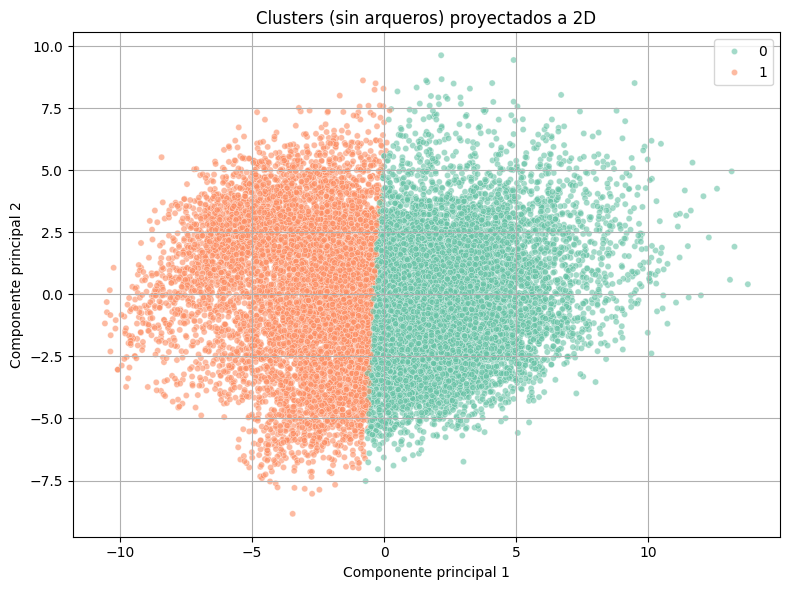

In [ ]:
# Obtener los datos proyectados a 2D (PCA sin arqueros)
# Reutilizamos el pipeline PCA trained on df_sin_arqueros
pca_sin_arqueros_2d = Pipeline([
    ("selector", FeatureSelector(
        excluir_patrones=["_id", "_name", "_number", "club_", "_gk"]
    )),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_reducido_sin_arqueros_2d = pca_sin_arqueros_2d.fit_transform(df_sin_arqueros)

# Obtener las etiquetas de cluster del pipeline entrenado sin arqueros
etiquetas_cluster_sin_arqueros = pipeline.pipeline.named_steps["cluster"].get_labels()

# Graficar la proyección 2D coloreada por las etiquetas de cluster
plot_scatter_pca(
    X_reducido_sin_arqueros_2d,
    etiquetas=etiquetas_cluster_sin_arqueros,
    titulo="Clusters (sin arqueros) proyectados a 2D"
)

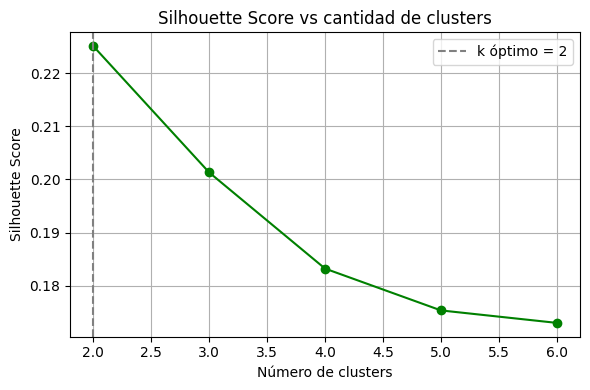

In [ ]:
pipeline.pipeline.named_steps["cluster"].plot_silhouette_curve()

Para entender mejor la composición de cada cluster, analizamos cómo se distribuyen las **posiciones simplificadas** dentro de cada uno.  
La siguiente tabla muestra la proporción de jugadores de cada posición que fue asignada a cada cluster:


In [ ]:
pd.crosstab(
    df_sin_arqueros_clusterizado["cluster"],
    df_sin_arqueros_clusterizado["posicion_simplificada"],
    normalize='columns'
).round(2)


posicion_simplificada,Defensor central,Delantero,Extremo,Lateral,Volante,Volante defensivo
cluster,,,,,,
0,0.11,0.7,0.8,0.46,0.78,0.56
1,0.89,0.3,0.2,0.54,0.22,0.44


Además de ver la distribución de posiciones, podemos comparar los **perfiles promedio de atributos** entre clusters.  
El siguiente gráfico de radar muestra cómo se diferencian en términos físicos y técnicos los jugadores agrupados en cada cluster.


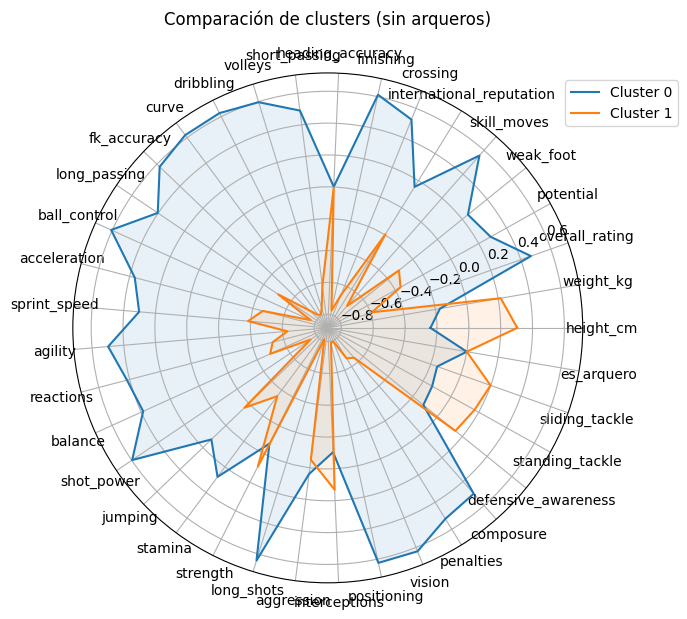

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pipeline_radar = Pipeline([
        ("selector",FeatureSelector(
                excluir_patrones=["_id", "_name", "_number", "club_", "gk_", "pca_"])),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
])

# Variables seleccionadas
X_sel = pipeline_radar.fit_transform(df_sin_arqueros_clusterizado)

# Obtener los nombres de features del selector
columnas = pipeline_radar.named_steps["selector"].columnas_seleccionadas_

# Convertir a DataFrame
X_sel_df = pd.DataFrame(X_sel, columns=columnas, index=df_sin_arqueros_clusterizado.index)

# Etiquetas de cluster
etiquetas = df_sin_arqueros_clusterizado["cluster"]

# Promedios por cluster
def plot_radar_clusters(X, labels, titulo="Radar por cluster"):
    """
    Dibuja un gráfico de radar comparando los promedios de cada cluster.

    Parámetros:
    - X: DataFrame con variables numéricas seleccionadas (ya transformadas)
    - labels: Series o array con la etiqueta de cluster de cada fila
    - titulo: título del gráfico
    """
    df_mean = X.copy()
    df_mean["cluster"] = labels
    medias = df_mean.groupby("cluster").mean()

    categorias = medias.columns.tolist()
    N = len(categorias)

    # Ángulos para cada eje
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # cerrar el círculo

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for i, row in medias.iterrows():
        valores = row.tolist()
        valores += valores[:1]
        ax.plot(angles, valores, label=f"Cluster {i}")
        ax.fill(angles, valores, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categorias, fontsize=10)
    ax.set_title(titulo, y=1.08)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
    plt.tight_layout()
    plt.show()

# Graficar radar
plot_radar_clusters(X_sel_df, etiquetas, titulo="Comparación de clusters (sin arqueros)")


### Interpretación de los clusters (jugadores de campo)

Luego de excluir a los arqueros y aplicar reducción de dimensionalidad + clustering automático, el modelo encontró **dos grupos bien diferenciados**. Al analizar la distribución de posiciones y las medias de atributos físicos y técnicos, podemos proponer la siguiente interpretación:

* **Cluster 0** agrupa en su mayoría a **jugadores ofensivos**: extremos (80%), delanteros (70%) y volantes (78%). Su perfil técnico destaca por:

  * Mayor velocidad (`sprint_speed`, `acceleration`)
  * Más habilidad con la pelota (`dribbling`, `curve`, `ball_control`)
  * Mejor pase y tiro (`short_passing`, `long_shots`, `fk_accuracy`)
  * Menor altura, peso y fuerza

* **Cluster 1** concentra a los **jugadores defensivos**, especialmente defensores centrales (89%) y volantes defensivos. Sus atributos más representativos son:

  * Mayor fuerza (`strength`, `aggression`, `jumping`)
  * Mejor capacidad de marcaje (`interceptions`, `defensive_awareness`, `sliding_tackle`)
  * Mayor estatura y peso
  * Menor destreza técnica en regate y tiro

El gráfico de radar confirma este contraste: el perfil de Cluster 0 está alineado con **la creación de juego y el desequilibrio**, mientras que el de Cluster 1 responde a **contención y defensa posicional**.

